# Notebook definitivo consolidado — NovaPet

Este notebook consolida el flujo de entrenamiento del proyecto NovaPet a partir del Kardex actualizado, incorporando:

- transformación del Kardex a dataset supervisado,
- baseline (promedio móvil de 4 semanas),
- Random Forest,
- XGBoost,
- métricas estándar (MAE, RMSE, R²),
- gráficos comparativos,
- guardado de evidencia y modelos,
- y una sección de reproducibilidad.

In [1]:
!pip -q install xgboost

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

## 1. Cargar archivo Kardex

Sube tu archivo a Colab y ajusta el nombre si hace falta.

In [3]:
ruta_kardex = "/content/kardex_actualizado_febrero_2026.xlsx"

df_raw = pd.read_excel(ruta_kardex)
print("Archivo cargado correctamente")
print("Dimensiones:", df_raw.shape)
display(df_raw.head())

Archivo cargado correctamente
Dimensiones: (744, 13)


,Código de Producto,Nº Movimiento,Fecha,Nombre,Marca,Almacen,Tipo de Movimiento,Cantidad,Costo Unitario,Saldo Stock,Costo Unitario Promedio,Costo Total Inventario,Costo Total Venta
0,11,23244509,2025-05-27 11:26:28,VACUNA C6/CV,RECOMBITECK,VACUNAS,ENTRADA,15,6.12,15.0,6.12,91.80,NaN
1,12,23244510,2025-05-27 11:32:07,RABISIN,BOEHRINGER INGELHEIM,VACUNAS,ENTRADA,7,2.52,7.0,2.52,17.64,NaN
2,13,23244511,2025-05-27 11:44:58,DEFENSOR,ZOETIS,VACUNAS,ENTRADA,6,2.76,6.0,2.76,16.56,NaN
3,14,23244512,2025-05-27 11:48:21,BRONCHICINE,ZOETIS,VACUNAS,ENTRADA,11,4.60,11.0,4.60,50.60,NaN
4,15,23244513,2025-05-27 11:58:46,FELOCELL 3,ZOETIS,VACUNAS,ENTRADA,1,6.42,1.0,6.42,6.42,NaN


## 2. Inspección inicial del archivo

In [4]:
print("Columnas originales:")
print(df_raw.columns.tolist())

print("\nTipos de dato:")
print(df_raw.dtypes)

print("\nValores nulos por columna:")
print(df_raw.isnull().sum())

Columnas originales:
['Código de Producto', 'Nº Movimiento', 'Fecha', 'Nombre', 'Marca', 'Almacen', 'Tipo de Movimiento', 'Cantidad', 'Costo Unitario', 'Saldo Stock', 'Costo Unitario Promedio', 'Costo Total Inventario', 'Costo Total Venta']

Tipos de dato:
Código de Producto                  int64
Nº Movimiento                       int64
Fecha                      datetime64[ns]
Nombre                             object
Marca                              object
Almacen                            object
Tipo de Movimiento                 object
Cantidad                            int64
Costo Unitario                    float64
Saldo Stock                       float64
Costo Unitario Promedio           float64
Costo Total Inventario            float64
Costo Total Venta                 float64
dtype: object

Valores nulos por columna:
Código de Producto           0
Nº Movimiento                0
Fecha                        0
Nombre                       0
Marca                        0


## 3. Limpieza y estandarización de columnas

In [5]:
df = df_raw.copy()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("ó", "o")
    .str.replace("á", "a")
    .str.replace("é", "e")
    .str.replace("í", "i")
    .str.replace("ú", "u")
    .str.replace("ñ", "n")
)

print("Columnas estandarizadas:")
print(df.columns.tolist())

Columnas estandarizadas:
['codigo_de_producto', 'nº_movimiento', 'fecha', 'nombre', 'marca', 'almacen', 'tipo_de_movimiento', 'cantidad', 'costo_unitario', 'saldo_stock', 'costo_unitario_promedio', 'costo_total_inventario', 'costo_total_venta']


## 4. Conversión de fecha y filtro de salidas

In [6]:
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Filtrar solo SALIDA = consumo real
df = df[df["tipo_de_movimiento"].astype(str).str.upper().str.strip() == "SALIDA"].copy()

print("Dimensiones tras filtrar SALIDA:", df.shape)
display(df.head())

Dimensiones tras filtrar SALIDA: (480, 13)


,codigo_de_producto,nº_movimiento,fecha,nombre,marca,almacen,tipo_de_movimiento,cantidad,costo_unitario,saldo_stock,costo_unitario_promedio,costo_total_inventario,costo_total_venta
15,22,23244617,2025-05-29 17:09:50,LIBRELA 10MG,ZOETIS,Principal,SALIDA,1,58.48,2.0,58.48,116.97,58.48
16,11,23244618,2025-05-29 17:18:32,VACUNA C6/CV,RECOMBITECK,VACUNAS,SALIDA,15,6.12,NaN,6.12,0.00,91.80
18,11,23244620,2025-05-29 17:23:13,VACUNA C6/CV,RECOMBITECK,VACUNAS,SALIDA,1,6.12,14.0,6.12,85.68,6.12
20,11,23244622,2025-05-29 17:31:50,VACUNA C6/CV,RECOMBITECK,VACUNAS,SALIDA,1,6.12,14.0,6.12,85.68,6.12
21,12,23244623,2025-05-29 17:31:50,RABISIN,BOEHRINGER INGELHEIM,VACUNAS,SALIDA,1,2.52,6.0,2.52,15.12,2.52


## 5. Crear variables temporales (año y semana ISO)

In [7]:
iso = df["fecha"].dt.isocalendar()
df["anio"] = iso.year.astype(int)
df["semana"] = iso.week.astype(int)

display(df[["fecha", "anio", "semana"]].head())

,fecha,anio,semana
15,2025-05-29 17:09:50,2025,22
16,2025-05-29 17:18:32,2025,22
18,2025-05-29 17:23:13,2025,22
20,2025-05-29 17:31:50,2025,22
21,2025-05-29 17:31:50,2025,22


## 6. Detectar columna de precio

In [8]:
if "costo_unitario_promedio" in df.columns:
    col_precio = "costo_unitario_promedio"
elif "costo_unitario" in df.columns:
    col_precio = "costo_unitario"
else:
    col_precio = None

print("Columna de precio detectada:", col_precio)

if col_precio is None:
    print("No se encontró una columna de precio. Se usará precio_unitario = 0.0")

Columna de precio detectada: costo_unitario_promedio


## 7. Construir consumo semanal por producto

In [9]:
agg_dict = {"cantidad": "sum"}
if col_precio is not None:
    agg_dict[col_precio] = "mean"

consumo = (
    df.groupby(["nombre", "almacen", "anio", "semana"], as_index=False)
      .agg(agg_dict)
)

rename_dict = {
    "nombre": "producto",
    "almacen": "categoria",
    "cantidad": "consumo_semanal"
}
if col_precio is not None:
    rename_dict[col_precio] = "precio_unitario"

consumo.rename(columns=rename_dict, inplace=True)

if "precio_unitario" not in consumo.columns:
    consumo["precio_unitario"] = 0.0

consumo = consumo.sort_values(["producto", "categoria", "anio", "semana"]).reset_index(drop=True)

print("Base semanal creada:")
print(consumo.shape)
display(consumo.head())

Base semanal creada:
(315, 6)


,producto,categoria,anio,semana,consumo_semanal,precio_unitario
0,AMOXICILINA + AC. CLAVULANICO 500 MG,FARMACIA,2026,6,3,0.85
1,BRONCHICINE,VACUNAS,2025,26,2,4.60
2,BRONCHICINE,VACUNAS,2025,27,1,4.60
3,BRONCHICINE,VACUNAS,2025,28,4,4.60
4,BRONCHICINE,VACUNAS,2025,29,1,4.60


## 8. Feature engineering real

In [10]:
consumo["lag_1"] = consumo.groupby(["producto", "categoria"])["consumo_semanal"].shift(1)
consumo["lag_2"] = consumo.groupby(["producto", "categoria"])["consumo_semanal"].shift(2)
consumo["lag_3"] = consumo.groupby(["producto", "categoria"])["consumo_semanal"].shift(3)
consumo["lag_4"] = consumo.groupby(["producto", "categoria"])["consumo_semanal"].shift(4)

consumo["promedio_4"] = consumo[["lag_1", "lag_2", "lag_3", "lag_4"]].mean(axis=1)

display(consumo.head(10))

,producto,categoria,anio,semana,consumo_semanal,precio_unitario,lag_1,lag_2,lag_3,lag_4,promedio_4
0,AMOXICILINA + AC. CLAVULANICO 500 MG,FARMACIA,2026,6,3,0.85,NaN,NaN,NaN,NaN,NaN
1,BRONCHICINE,VACUNAS,2025,26,2,4.60,NaN,NaN,NaN,NaN,NaN
2,BRONCHICINE,VACUNAS,2025,27,1,4.60,2.0,NaN,NaN,NaN,2.000000
3,BRONCHICINE,VACUNAS,2025,28,4,4.60,1.0,2.0,NaN,NaN,1.500000
4,BRONCHICINE,VACUNAS,2025,29,1,4.60,4.0,1.0,2.0,NaN,2.333333
5,BRONCHICINE,VACUNAS,2025,30,2,4.60,1.0,4.0,1.0,2.0,2.000000
6,BRONCHICINE,VACUNAS,2025,31,3,4.60,2.0,1.0,4.0,1.0,2.000000
7,BRONCHICINE,VACUNAS,2025,33,2,4.60,3.0,2.0,1.0,4.0,2.500000
8,BRONCHICINE,VACUNAS,2025,34,1,4.60,2.0,3.0,2.0,1.0,2.000000
9,BRONCHICINE,VACUNAS,2025,38,1,4.60,1.0,2.0,3.0,2.0,2.000000


## 9. Construir dataset supervisado final

In [11]:
dataset_ml = consumo.dropna(
    subset=["lag_1", "lag_2", "lag_3", "lag_4", "promedio_4"]
).copy()

dataset_ml = dataset_ml[[
    "producto",
    "categoria",
    "anio",
    "semana",
    "precio_unitario",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_4",
    "consumo_semanal"
]].reset_index(drop=True)

print("Dataset supervisado final:")
print("Filas y columnas:", dataset_ml.shape)
display(dataset_ml.head())

Dataset supervisado final:
Filas y columnas: (148, 11)


,producto,categoria,anio,semana,precio_unitario,lag_1,lag_2,lag_3,lag_4,promedio_4,consumo_semanal
0,BRONCHICINE,VACUNAS,2025,30,4.6,1.0,4.0,1.0,2.0,2.0,2
1,BRONCHICINE,VACUNAS,2025,31,4.6,2.0,1.0,4.0,1.0,2.0,3
2,BRONCHICINE,VACUNAS,2025,33,4.6,3.0,2.0,1.0,4.0,2.5,2
3,BRONCHICINE,VACUNAS,2025,34,4.6,2.0,3.0,2.0,1.0,2.0,1
4,BRONCHICINE,VACUNAS,2025,38,4.6,1.0,2.0,3.0,2.0,2.0,1


## 10. Verificación rápida del dataset supervisado

In [12]:
print("Valores nulos:")
print(dataset_ml.isnull().sum())

print("\nResumen estadístico:")
display(dataset_ml.describe(include="all"))

Valores nulos:
producto           0
categoria          0
anio               0
semana             0
precio_unitario    0
lag_1              0
lag_2              0
lag_3              0
lag_4              0
promedio_4         0
consumo_semanal    0
dtype: int64

Resumen estadístico:


,producto,categoria,anio,semana,precio_unitario,lag_1,lag_2,lag_3,lag_4,promedio_4,consumo_semanal
count,148,148,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000,148.000000
unique,18,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,RABISIN,VACUNAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,29,102,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,2025.418919,26.871622,4.579797,3.466216,3.263514,3.324324,4.202703,3.564189,3.506757
std,NaN,NaN,0.495057,19.464700,3.220491,5.705249,4.371151,4.338118,9.315308,5.170324,6.013021
min,NaN,NaN,2025.000000,1.000000,0.080000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,NaN,NaN,2025.000000,6.000000,2.520000,1.000000,1.000000,1.000000,1.000000,1.500000,1.000000
50%,NaN,NaN,2025.000000,32.000000,4.470000,2.000000,2.000000,2.000000,2.000000,2.500000,2.000000
75%,NaN,NaN,2026.000000,46.000000,6.120000,3.000000,3.000000,4.000000,4.000000,3.750000,4.000000


## 11. Definir X e y

In [13]:
dataset_ordenado = dataset_ml.sort_values(["anio", "semana"]).reset_index(drop=True)

X = dataset_ordenado.drop(columns=["consumo_semanal"])
y = dataset_ordenado["consumo_semanal"]

cat_cols = ["producto", "categoria"]
num_cols = ["anio", "semana", "precio_unitario", "lag_1", "lag_2", "lag_3", "lag_4", "promedio_4"]

print("Variables explicativas (X):")
print(X.columns.tolist())

print("\nVariable objetivo (y): consumo_semanal")

Variables explicativas (X):
['producto', 'categoria', 'anio', 'semana', 'precio_unitario', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'promedio_4']

Variable objetivo (y): consumo_semanal


## 12. Split temporal (train / test)

In [14]:
split_idx = int(len(dataset_ordenado) * 0.75)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

print("Tamaño total:", dataset_ordenado.shape)
print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nÚltimas semanas en train:")
display(dataset_ordenado.iloc[:split_idx][["anio", "semana"]].drop_duplicates().tail())

print("\nPrimeras semanas en test:")
display(dataset_ordenado.iloc[split_idx:][["anio", "semana"]].drop_duplicates().head())

Tamaño total: (148, 11)
Train: (111, 10)
Test : (37, 10)

Últimas semanas en train:


,anio,semana
80,2025,52
86,2026,1
91,2026,2
99,2026,3
105,2026,4



Primeras semanas en test:


,anio,semana
111,2026,4
112,2026,5
117,2026,6
128,2026,7
133,2026,8


## 13. Preprocesamiento (OneHot + numéricas)

In [15]:
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

## 14. Baseline — promedio móvil de 4 semanas

In [16]:
pred_baseline = X_test["promedio_4"].values

baseline_mae = mean_absolute_error(y_test, pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, pred_baseline))
baseline_r2 = r2_score(y_test, pred_baseline)

print("=== Baseline: Promedio móvil 4 semanas ===")
print(f"MAE : {baseline_mae:.3f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"R²  : {baseline_r2:.3f}")

=== Baseline: Promedio móvil 4 semanas ===
MAE : 1.797
RMSE: 3.067
R²  : 0.583


## 15. Entrenamiento Random Forest

In [17]:
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, pred_rf))
rf_r2 = r2_score(y_test, pred_rf)

print("=== Random Forest ===")
print(f"MAE : {rf_mae:.3f}")
print(f"RMSE: {rf_rmse:.3f}")
print(f"R²  : {rf_r2:.3f}")

=== Random Forest ===
MAE : 2.178
RMSE: 4.139
R²  : 0.241


## 16. Entrenamiento XGBoost

In [18]:
xgb = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

xgb_mae = mean_absolute_error(y_test, pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, pred_xgb))
xgb_r2 = r2_score(y_test, pred_xgb)

print("=== XGBoost ===")
print(f"MAE : {xgb_mae:.3f}")
print(f"RMSE: {xgb_rmse:.3f}")
print(f"R²  : {xgb_r2:.3f}")

=== XGBoost ===
MAE : 2.559
RMSE: 4.148
R²  : 0.238


## 17. Tabla comparativa final

In [19]:
comparacion = pd.DataFrame({
    "Modelo": [
        "Baseline (Promedio móvil 4 semanas)",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [baseline_mae, rf_mae, xgb_mae],
    "RMSE": [baseline_rmse, rf_rmse, xgb_rmse],
    "R2": [baseline_r2, rf_r2, xgb_r2]
})

comparacion["Mejora_MAE_vs_Baseline_%"] = (
    (baseline_mae - comparacion["MAE"]) / baseline_mae * 100
).round(2)

comparacion.loc[
    comparacion["Modelo"] == "Baseline (Promedio móvil 4 semanas)",
    "Mejora_MAE_vs_Baseline_%"
] = 0.0

comparacion = comparacion.sort_values("MAE").reset_index(drop=True)

print("=== Comparación de modelos ===")
display(comparacion)

=== Comparación de modelos ===


,Modelo,MAE,RMSE,R2,Mejora_MAE_vs_Baseline_%
0,Baseline (Promedio móvil 4 semanas),1.797297,3.067374,0.582989,0.00
1,Random Forest,2.178378,4.139377,0.240577,-21.20
2,XGBoost,2.559225,4.147657,0.237536,-42.39


## 18. Gráfico comparativo de errores

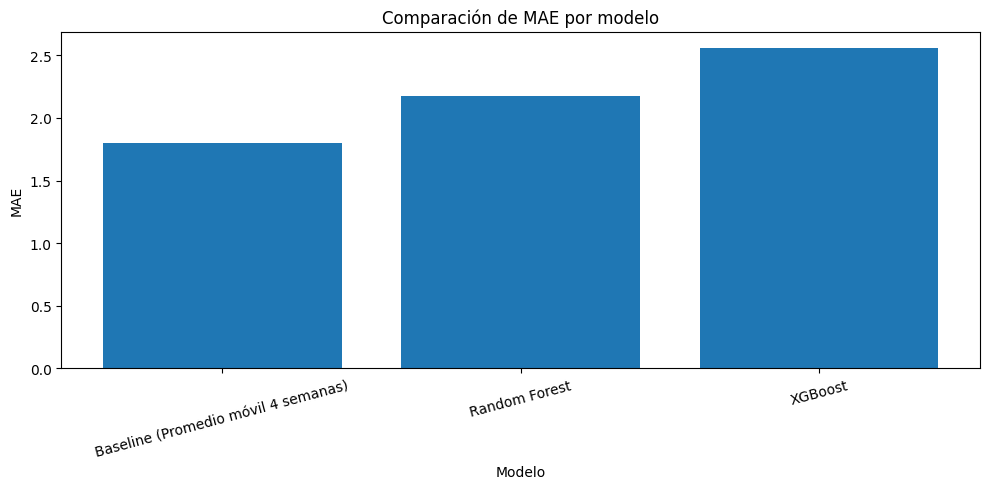

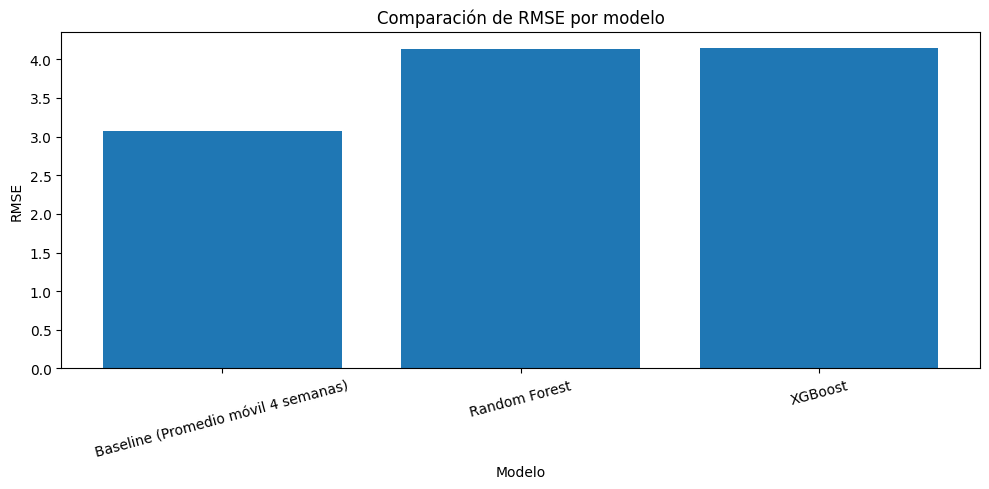

In [20]:
plt.figure(figsize=(10, 5))
plt.bar(comparacion["Modelo"], comparacion["MAE"])
plt.title("Comparación de MAE por modelo")
plt.ylabel("MAE")
plt.xlabel("Modelo")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(comparacion["Modelo"], comparacion["RMSE"])
plt.title("Comparación de RMSE por modelo")
plt.ylabel("RMSE")
plt.xlabel("Modelo")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 19. Valores reales vs predicciones

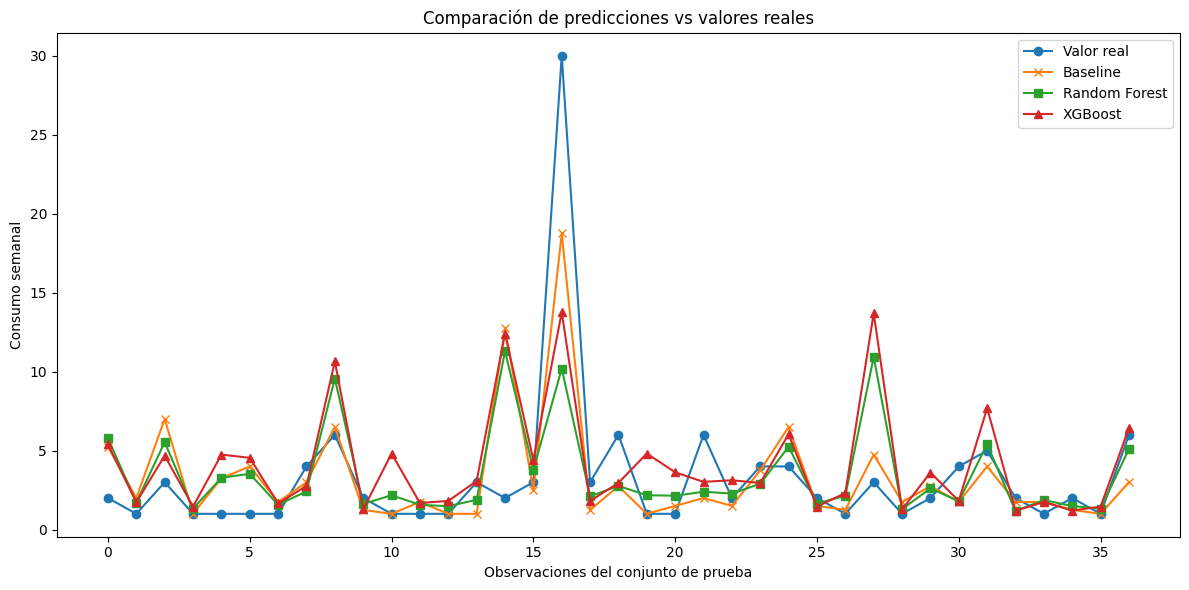

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Valor real", marker="o")
plt.plot(pred_baseline, label="Baseline", marker="x")
plt.plot(pred_rf, label="Random Forest", marker="s")
plt.plot(pred_xgb, label="XGBoost", marker="^")

plt.title("Comparación de predicciones vs valores reales")
plt.xlabel("Observaciones del conjunto de prueba")
plt.ylabel("Consumo semanal")
plt.legend()
plt.tight_layout()
plt.show()

## 20. Residuos por modelo

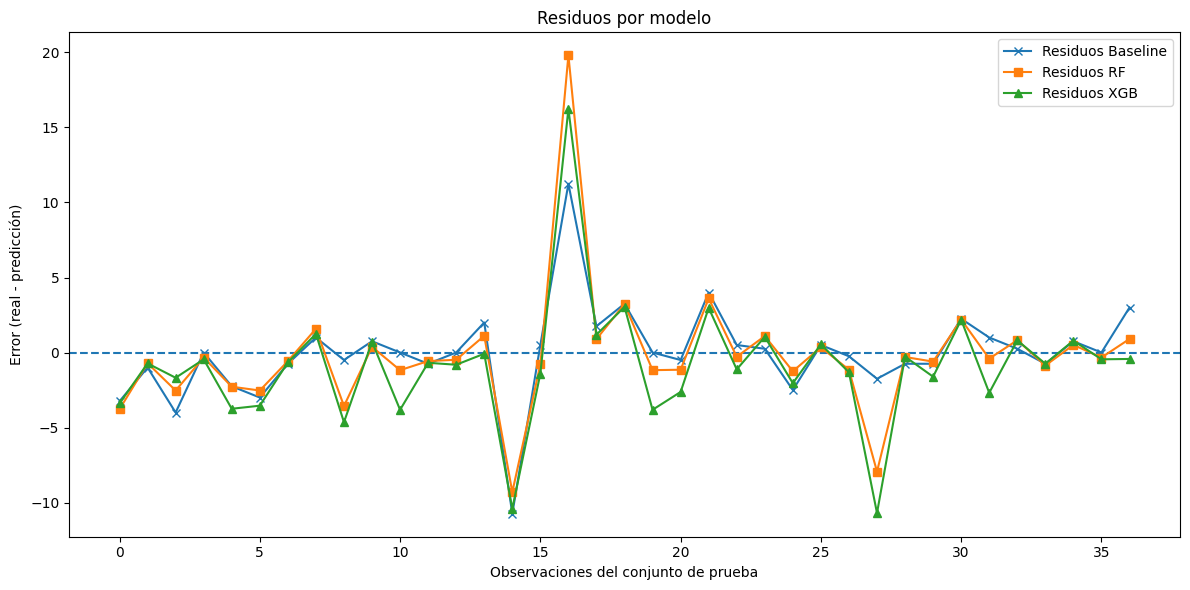

In [22]:
res_baseline = y_test.values - pred_baseline
res_rf = y_test.values - pred_rf
res_xgb = y_test.values - pred_xgb

plt.figure(figsize=(12, 6))
plt.axhline(y=0, linestyle="--")
plt.plot(res_baseline, label="Residuos Baseline", marker="x")
plt.plot(res_rf, label="Residuos RF", marker="s")
plt.plot(res_xgb, label="Residuos XGB", marker="^")
plt.title("Residuos por modelo")
plt.xlabel("Observaciones del conjunto de prueba")
plt.ylabel("Error (real - predicción)")
plt.legend()
plt.tight_layout()
plt.show()

## 21. Selección automática del mejor modelo

In [23]:
mejor_fila = comparacion.sort_values("MAE").iloc[0]
mejor_modelo = mejor_fila["Modelo"]
mejor_mae = mejor_fila["MAE"]
mejor_rmse = mejor_fila["RMSE"]
mejor_r2 = mejor_fila["R2"]

print(f"✅ Mejor modelo según MAE: {mejor_modelo}")
print(f"MAE  = {mejor_mae:.3f}")
print(f"RMSE = {mejor_rmse:.3f}")
print(f"R²   = {mejor_r2:.3f}")

✅ Mejor modelo según MAE: Baseline (Promedio móvil 4 semanas)
MAE  = 1.797
RMSE = 3.067
R²   = 0.583


## 22. Resumen automático en lenguaje académico

In [24]:
baseline_fila = comparacion[comparacion["Modelo"] == "Baseline (Promedio móvil 4 semanas)"].iloc[0]
baseline_mae_txt = baseline_fila["MAE"]
baseline_rmse_txt = baseline_fila["RMSE"]
baseline_r2_txt = baseline_fila["R2"]

mejora_pct = ((baseline_mae_txt - mejor_mae) / baseline_mae_txt) * 100

resumen_automatico = f"""
Resumen automático de resultados

A partir del Kardex actualizado, se construyó un dataset supervisado con {dataset_ordenado.shape[0]} observaciones,
donde la variable objetivo corresponde al consumo semanal por ítem. Se aplicó una partición temporal del conjunto
de datos, destinando {X_train.shape[0]} registros al entrenamiento y {X_test.shape[0]} registros a prueba,
preservando el orden cronológico.

Como modelo baseline se utilizó un promedio móvil de 4 semanas, obteniendo un MAE de {baseline_mae_txt:.3f},
un RMSE de {baseline_rmse_txt:.3f} y un R² de {baseline_r2_txt:.3f}. Posteriormente se entrenaron dos modelos
avanzados de aprendizaje automático: Random Forest Regressor y XGBoost Regressor.

El mejor desempeño, según la métrica principal MAE, correspondió a: {mejor_modelo}, con un MAE de {mejor_mae:.3f},
un RMSE de {mejor_rmse:.3f} y un R² de {mejor_r2:.3f}. En comparación con el baseline, este resultado representa
una mejora del {mejora_pct:.2f}% en el error absoluto medio.

Estos resultados permiten identificar el enfoque más robusto para estimar el consumo semanal de medicamentos y vacunas
en NovaPet. No obstante, la interpretación debe considerar el tamaño del dataset y la longitud limitada de las series
históricas por producto, factores que pueden restringir la estabilidad del R² y la generalización del modelo.
"""

print(resumen_automatico)


Resumen automático de resultados

A partir del Kardex actualizado, se construyó un dataset supervisado con 148 observaciones,
donde la variable objetivo corresponde al consumo semanal por ítem. Se aplicó una partición temporal del conjunto
de datos, destinando 111 registros al entrenamiento y 37 registros a prueba,
preservando el orden cronológico.

Como modelo baseline se utilizó un promedio móvil de 4 semanas, obteniendo un MAE de 1.797,
un RMSE de 3.067 y un R² de 0.583. Posteriormente se entrenaron dos modelos
avanzados de aprendizaje automático: Random Forest Regressor y XGBoost Regressor.

El mejor desempeño, según la métrica principal MAE, correspondió a: Baseline (Promedio móvil 4 semanas), con un MAE de 1.797,
un RMSE de 3.067 y un R² de 0.583. En comparación con el baseline, este resultado representa
una mejora del 0.00% en el error absoluto medio.

Estos resultados permiten identificar el enfoque más robusto para estimar el consumo semanal de medicamentos y vacunas
en NovaP

## 23. Guardar evidencia

In [25]:
comparacion.to_csv("/content/comparacion_modelos_novapet.csv", index=False)

evidencia_pred = X_test.copy()
evidencia_pred["y_real"] = y_test.values
evidencia_pred["pred_baseline"] = pred_baseline
evidencia_pred["pred_rf"] = pred_rf
evidencia_pred["pred_xgb"] = pred_xgb
evidencia_pred.to_csv("/content/evidencia_predicciones_novapet.csv", index=False)

with open("/content/resumen_resultados_novapet.txt", "w", encoding="utf-8") as f:
    f.write(resumen_automatico)

print("Archivos guardados:")
print("- /content/comparacion_modelos_novapet.csv")
print("- /content/evidencia_predicciones_novapet.csv")
print("- /content/resumen_resultados_novapet.txt")

Archivos guardados:
- /content/comparacion_modelos_novapet.csv
- /content/evidencia_predicciones_novapet.csv
- /content/resumen_resultados_novapet.txt


## 24. Guardar modelos entrenados

In [26]:
joblib.dump(rf, "/content/modelo_rf_inventario_novapet.pkl")
joblib.dump(xgb, "/content/modelo_xgb_inventario_novapet.pkl")

print("Modelos guardados:")
print("- /content/modelo_rf_inventario_novapet.pkl")
print("- /content/modelo_xgb_inventario_novapet.pkl")

Modelos guardados:
- /content/modelo_rf_inventario_novapet.pkl
- /content/modelo_xgb_inventario_novapet.pkl


## 25. Guardar gráficos

In [27]:
# Gráfico MAE
plt.figure(figsize=(10, 5))
plt.bar(comparacion["Modelo"], comparacion["MAE"])
plt.title("Comparación de MAE por modelo")
plt.ylabel("MAE")
plt.xlabel("Modelo")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/content/grafico_mae_modelos.png", dpi=300)
plt.close()

# Gráfico RMSE
plt.figure(figsize=(10, 5))
plt.bar(comparacion["Modelo"], comparacion["RMSE"])
plt.title("Comparación de RMSE por modelo")
plt.ylabel("RMSE")
plt.xlabel("Modelo")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("/content/grafico_rmse_modelos.png", dpi=300)
plt.close()

# Gráfico predicciones vs real
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Valor real", marker="o")
plt.plot(pred_baseline, label="Baseline", marker="x")
plt.plot(pred_rf, label="Random Forest", marker="s")
plt.plot(pred_xgb, label="XGBoost", marker="^")
plt.title("Comparación de predicciones vs valores reales")
plt.xlabel("Observaciones del conjunto de prueba")
plt.ylabel("Consumo semanal")
plt.legend()
plt.tight_layout()
plt.savefig("/content/grafico_predicciones_vs_real.png", dpi=300)
plt.close()

print("Gráficos guardados:")
print("- /content/grafico_mae_modelos.png")
print("- /content/grafico_rmse_modelos.png")
print("- /content/grafico_predicciones_vs_real.png")

Gráficos guardados:
- /content/grafico_mae_modelos.png
- /content/grafico_rmse_modelos.png
- /content/grafico_predicciones_vs_real.png


## 26. Versiones de librerías (reproducibilidad)

In [28]:
import sklearn
import xgboost
import matplotlib

print("=== Versiones de librerías ===")
print("pandas      :", pd.__version__)
print("numpy       :", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", xgboost.__version__)
print("matplotlib  :", matplotlib.__version__)
print("joblib      :", joblib.__version__)

=== Versiones de librerías ===
pandas      : 2.2.2
numpy       : 2.0.2
scikit-learn: 1.6.1
xgboost     : 3.2.0
matplotlib  : 3.10.0
joblib      : 1.5.3


# NovaPet - Notebook de mejoras integradas

Este notebook integra los bloques adicionales propuestos para fortalecer el pipeline del proyecto de titulación:

- evidencia de ampliación del dataset,
- nuevas variables derivadas,
- reentrenamiento con features mejoradas,
- validación walk-forward,
- tuning básico,
- evaluación por rotación,
- comparación antes vs después,
- hallazgos finales automáticos,
- y guardado de evidencias.

> **Importante:** este notebook asume que ya ejecutaste previamente el notebook consolidado base y que existen en memoria variables como:
> `consumo`, `dataset_ml`, `dataset_ordenado`, `comparacion`, `mean_absolute_error`, `mean_squared_error`, `r2_score`,
> `RandomForestRegressor`, `XGBRegressor`, `Pipeline`, `ColumnTransformer`, `OneHotEncoder`, etc.

## A) Evidencia de ampliación del dataset

In [29]:
# =========================================================
# A) EVIDENCIA DE AMPLIACIÓN DEL DATASET
# =========================================================

print("=== Evidencia de ampliación del dataset ===")
print(f"Total de registros supervisados: {len(dataset_ml)}")
print(f"Productos únicos: {dataset_ml['producto'].nunique()}")
print(f"Categorías únicas: {dataset_ml['categoria'].nunique()}")

rango_temporal = dataset_ordenado[["anio", "semana"]].drop_duplicates()
print(f"Total de semanas únicas: {len(rango_temporal)}")

print("\nPrimeras semanas disponibles:")
display(rango_temporal.head(10))

print("\nÚltimas semanas disponibles:")
display(rango_temporal.tail(10))

print("\nFrecuencia por producto (primeros 10):")
display(
    dataset_ml.groupby("producto")["consumo_semanal"]
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name="n_registros")
)

=== Evidencia de ampliación del dataset ===
Total de registros supervisados: 148
Productos únicos: 18
Categorías únicas: 3
Total de semanas únicas: 30

Primeras semanas disponibles:


,anio,semana
0,2025,28
2,2025,29
4,2025,30
7,2025,31
11,2025,32
13,2025,33
16,2025,34
19,2025,35
23,2025,36
26,2025,38



Últimas semanas disponibles:


,anio,semana
80,2025,52
86,2026,1
91,2026,2
99,2026,3
105,2026,4
112,2026,5
117,2026,6
128,2026,7
133,2026,8
141,2026,9



Frecuencia por producto (primeros 10):


,producto,n_registros
0,RABISIN,29
1,VACUNA C6/CV,22
2,BRONCHICINE,21
3,FELOCELL 3,13
4,MELOXICAM 1.5MG 10ML,9
5,ENTEROCHRONIC,8
6,DAPPVL2,6
7,PREVICOX 227MG TABLETA,6
8,GALGOCAL 600mg,6
9,FELOCELL FELV LEUCEMIA,6


## B) Nuevas features derivadas

In [30]:
# =========================================================
# B) NUEVAS FEATURES DERIVADAS
# =========================================================

# Asegúrate de que consumo ya esté ordenado
consumo = consumo.sort_values(["producto", "categoria", "anio", "semana"]).reset_index(drop=True)

# Features adicionales
consumo["max_4"] = consumo[["lag_1", "lag_2", "lag_3", "lag_4"]].max(axis=1)
consumo["min_4"] = consumo[["lag_1", "lag_2", "lag_3", "lag_4"]].min(axis=1)
consumo["std_4"] = consumo[["lag_1", "lag_2", "lag_3", "lag_4"]].std(axis=1)
consumo["tendencia_2"] = consumo["lag_1"] - consumo["lag_2"]

# Reconstruir dataset supervisado con las nuevas features
dataset_ml_v2 = consumo.dropna(
    subset=[
        "lag_1", "lag_2", "lag_3", "lag_4", "promedio_4",
        "max_4", "min_4", "std_4", "tendencia_2"
    ]
).copy()

dataset_ml_v2 = dataset_ml_v2[[
    "producto",
    "categoria",
    "anio",
    "semana",
    "precio_unitario",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_4",
    "promedio_4",
    "max_4",
    "min_4",
    "std_4",
    "tendencia_2",
    "consumo_semanal"
]].reset_index(drop=True)

print("=== Dataset mejorado con nuevas features ===")
print("Dimensiones:", dataset_ml_v2.shape)
display(dataset_ml_v2.head())

=== Dataset mejorado con nuevas features ===
Dimensiones: (148, 15)


,producto,categoria,anio,semana,precio_unitario,lag_1,lag_2,lag_3,lag_4,promedio_4,max_4,min_4,std_4,tendencia_2,consumo_semanal
0,BRONCHICINE,VACUNAS,2025,30,4.6,1.0,4.0,1.0,2.0,2.0,4.0,1.0,1.414214,-3.0,2
1,BRONCHICINE,VACUNAS,2025,31,4.6,2.0,1.0,4.0,1.0,2.0,4.0,1.0,1.414214,1.0,3
2,BRONCHICINE,VACUNAS,2025,33,4.6,3.0,2.0,1.0,4.0,2.5,4.0,1.0,1.290994,1.0,2
3,BRONCHICINE,VACUNAS,2025,34,4.6,2.0,3.0,2.0,1.0,2.0,3.0,1.0,0.816497,-1.0,1
4,BRONCHICINE,VACUNAS,2025,38,4.6,1.0,2.0,3.0,2.0,2.0,3.0,1.0,0.816497,-1.0,1


## C) X / y con nuevas features

In [31]:
# =========================================================
# C) X / y CON NUEVAS FEATURES
# =========================================================

dataset_ordenado_v2 = dataset_ml_v2.sort_values(["anio", "semana"]).reset_index(drop=True)

X_v2 = dataset_ordenado_v2.drop(columns=["consumo_semanal"])
y_v2 = dataset_ordenado_v2["consumo_semanal"]

cat_cols_v2 = ["producto", "categoria"]
num_cols_v2 = [
    "anio", "semana", "precio_unitario",
    "lag_1", "lag_2", "lag_3", "lag_4",
    "promedio_4", "max_4", "min_4", "std_4", "tendencia_2"
]

split_idx_v2 = int(len(dataset_ordenado_v2) * 0.75)

X_train_v2 = X_v2.iloc[:split_idx_v2].copy()
X_test_v2  = X_v2.iloc[split_idx_v2:].copy()
y_train_v2 = y_v2.iloc[:split_idx_v2].copy()
y_test_v2  = y_v2.iloc[split_idx_v2:].copy()

preprocess_v2 = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_v2),
        ("num", "passthrough", num_cols_v2)
    ]
)

print("=== Split versión mejorada ===")
print("Train:", X_train_v2.shape)
print("Test :", X_test_v2.shape)

=== Split versión mejorada ===
Train: (111, 14)
Test : (37, 14)


## D) Reentrenamiento con nuevas features

In [32]:
# =========================================================
# D) REENTRENAMIENTO CON NUEVAS FEATURES
# =========================================================

# Baseline
pred_baseline_v2 = X_test_v2["promedio_4"].values
baseline_mae_v2 = mean_absolute_error(y_test_v2, pred_baseline_v2)
baseline_rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, pred_baseline_v2))
baseline_r2_v2 = r2_score(y_test_v2, pred_baseline_v2)

# Random Forest
rf_v2 = Pipeline(steps=[
    ("preprocess", preprocess_v2),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_v2.fit(X_train_v2, y_train_v2)
pred_rf_v2 = rf_v2.predict(X_test_v2)

rf_mae_v2 = mean_absolute_error(y_test_v2, pred_rf_v2)
rf_rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, pred_rf_v2))
rf_r2_v2 = r2_score(y_test_v2, pred_rf_v2)

# XGBoost
xgb_v2 = Pipeline(steps=[
    ("preprocess", preprocess_v2),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    ))
])

xgb_v2.fit(X_train_v2, y_train_v2)
pred_xgb_v2 = xgb_v2.predict(X_test_v2)

xgb_mae_v2 = mean_absolute_error(y_test_v2, pred_xgb_v2)
xgb_rmse_v2 = np.sqrt(mean_squared_error(y_test_v2, pred_xgb_v2))
xgb_r2_v2 = r2_score(y_test_v2, pred_xgb_v2)

comparacion_v2 = pd.DataFrame({
    "Modelo": [
        "Baseline (Promedio móvil 4 semanas)",
        "Random Forest v2",
        "XGBoost v2"
    ],
    "MAE": [baseline_mae_v2, rf_mae_v2, xgb_mae_v2],
    "RMSE": [baseline_rmse_v2, rf_rmse_v2, xgb_rmse_v2],
    "R2": [baseline_r2_v2, rf_r2_v2, xgb_r2_v2]
})

comparacion_v2["Mejora_MAE_vs_Baseline_%"] = (
    (baseline_mae_v2 - comparacion_v2["MAE"]) / baseline_mae_v2 * 100
).round(2)

comparacion_v2.loc[
    comparacion_v2["Modelo"] == "Baseline (Promedio móvil 4 semanas)",
    "Mejora_MAE_vs_Baseline_%"
] = 0.0

comparacion_v2 = comparacion_v2.sort_values("MAE").reset_index(drop=True)

print("=== Resultados versión mejorada ===")
display(comparacion_v2)

=== Resultados versión mejorada ===


,Modelo,MAE,RMSE,R2,Mejora_MAE_vs_Baseline_%
0,Baseline (Promedio móvil 4 semanas),1.797297,3.067374,0.582989,0.00
1,Random Forest v2,2.090901,4.098404,0.255537,-16.34
2,XGBoost v2,2.441419,4.296455,0.181848,-35.84


## E) Validación walk-forward simple

In [33]:
# =========================================================
# E) VALIDACIÓN WALK-FORWARD SIMPLE
# =========================================================

# Parámetros de ventanas
n_total = len(dataset_ordenado_v2)
initial_train_size = int(n_total * 0.50)
step_size = max(5, int(n_total * 0.10))
test_window = max(5, int(n_total * 0.10))

resultados_walk = []

start_train = 0
end_train = initial_train_size

while (end_train + test_window) <= n_total:
    X_train_w = X_v2.iloc[start_train:end_train].copy()
    y_train_w = y_v2.iloc[start_train:end_train].copy()

    X_test_w = X_v2.iloc[end_train:end_train + test_window].copy()
    y_test_w = y_v2.iloc[end_train:end_train + test_window].copy()

    # Baseline
    pred_base_w = X_test_w["promedio_4"].values
    mae_base_w = mean_absolute_error(y_test_w, pred_base_w)

    # RF
    rf_w = Pipeline(steps=[
        ("preprocess", preprocess_v2),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ))
    ])
    rf_w.fit(X_train_w, y_train_w)
    pred_rf_w = rf_w.predict(X_test_w)
    mae_rf_w = mean_absolute_error(y_test_w, pred_rf_w)

    # XGB
    xgb_w = Pipeline(steps=[
        ("preprocess", preprocess_v2),
        ("model", XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=4,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])
    xgb_w.fit(X_train_w, y_train_w)
    pred_xgb_w = xgb_w.predict(X_test_w)
    mae_xgb_w = mean_absolute_error(y_test_w, pred_xgb_w)

    resultados_walk.append({
        "train_hasta": end_train,
        "test_hasta": end_train + test_window,
        "MAE_Baseline": mae_base_w,
        "MAE_RF": mae_rf_w,
        "MAE_XGB": mae_xgb_w
    })

    end_train += step_size

walk_df = pd.DataFrame(resultados_walk)

print("=== Walk-forward validation ===")
display(walk_df)

print("\nPromedio de MAE por modelo en walk-forward:")
display(
    pd.DataFrame({
        "Modelo": ["Baseline", "Random Forest", "XGBoost"],
        "MAE_promedio": [
            walk_df["MAE_Baseline"].mean(),
            walk_df["MAE_RF"].mean(),
            walk_df["MAE_XGB"].mean()
        ],
        "MAE_std": [
            walk_df["MAE_Baseline"].std(),
            walk_df["MAE_RF"].std(),
            walk_df["MAE_XGB"].std()
        ]
    })
)

=== Walk-forward validation ===


,train_hasta,test_hasta,MAE_Baseline,MAE_RF,MAE_XGB
0,74,88,2.035714,1.940952,1.861934
1,88,102,2.446429,2.494048,1.899669
2,102,116,3.428571,6.331190,6.255440
3,116,130,2.589286,3.055000,3.367470
4,130,144,1.089286,1.602857,2.370580



Promedio de MAE por modelo en walk-forward:


,Modelo,MAE_promedio,MAE_std
0,Baseline,2.317857,0.853358
1,Random Forest,3.084810,1.896936
2,XGBoost,3.151019,1.838544


## F) Tuning básico y factible

In [34]:
# =========================================================
# F) TUNING BÁSICO Y FACTIBLE
# =========================================================

resultados_tuning = []

# Random Forest
rf_configs = [
    {"n_estimators": 200, "max_depth": None},
    {"n_estimators": 400, "max_depth": None},
    {"n_estimators": 300, "max_depth": 8},
]

for cfg in rf_configs:
    model = Pipeline(steps=[
        ("preprocess", preprocess_v2),
        ("model", RandomForestRegressor(
            n_estimators=cfg["n_estimators"],
            max_depth=cfg["max_depth"],
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train_v2, y_train_v2)
    pred = model.predict(X_test_v2)

    resultados_tuning.append({
        "Modelo": "Random Forest",
        "Config": str(cfg),
        "MAE": mean_absolute_error(y_test_v2, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_v2, pred)),
        "R2": r2_score(y_test_v2, pred)
    })

# XGBoost
xgb_configs = [
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 3},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4},
    {"n_estimators": 300, "learning_rate": 0.10, "max_depth": 3},
]

for cfg in xgb_configs:
    model = Pipeline(steps=[
        ("preprocess", preprocess_v2),
        ("model", XGBRegressor(
            n_estimators=cfg["n_estimators"],
            learning_rate=cfg["learning_rate"],
            max_depth=cfg["max_depth"],
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42,
            n_jobs=-1
        ))
    ])

    model.fit(X_train_v2, y_train_v2)
    pred = model.predict(X_test_v2)

    resultados_tuning.append({
        "Modelo": "XGBoost",
        "Config": str(cfg),
        "MAE": mean_absolute_error(y_test_v2, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test_v2, pred)),
        "R2": r2_score(y_test_v2, pred)
    })

tuning_df = pd.DataFrame(resultados_tuning).sort_values("MAE").reset_index(drop=True)

print("=== Resultados tuning básico ===")
display(tuning_df)

=== Resultados tuning básico ===


,Modelo,Config,MAE,RMSE,R2
0,Random Forest,"{'n_estimators': 200, 'max_depth': None}",2.083378,4.076508,0.263470
1,Random Forest,"{'n_estimators': 300, 'max_depth': 8}",2.085074,4.058806,0.269853
2,Random Forest,"{'n_estimators': 400, 'max_depth': None}",2.102162,4.120107,0.247631
3,XGBoost,"{'n_estimators': 300, 'learning_rate': 0.05, '...",2.441419,4.296455,0.181848
4,XGBoost,"{'n_estimators': 300, 'learning_rate': 0.05, '...",2.497861,4.472145,0.113568
5,XGBoost,"{'n_estimators': 300, 'learning_rate': 0.1, 'm...",2.506580,4.361559,0.156865


## G) Evaluación por productos de alta y baja rotación

In [35]:
# =========================================================
# G) EVALUACIÓN POR ALTA Y BAJA ROTACIÓN
# =========================================================

rotacion = (
    dataset_ml_v2.groupby("producto")["consumo_semanal"]
    .mean()
    .reset_index(name="consumo_promedio")
)

mediana_rotacion = rotacion["consumo_promedio"].median()
rotacion["grupo_rotacion"] = np.where(
    rotacion["consumo_promedio"] >= mediana_rotacion,
    "Alta rotación",
    "Baja rotación"
)

test_eval = X_test_v2.copy()
test_eval["y_real"] = y_test_v2.values
test_eval["pred_baseline"] = pred_baseline_v2
test_eval["pred_rf"] = pred_rf_v2
test_eval["pred_xgb"] = pred_xgb_v2

test_eval = test_eval.merge(
    rotacion[["producto", "grupo_rotacion"]],
    on="producto",
    how="left"
)

def mae_group(df, y_col, pred_col):
    return mean_absolute_error(df[y_col], df[pred_col])

resumen_rotacion = []

for grupo in ["Alta rotación", "Baja rotación"]:
    df_g = test_eval[test_eval["grupo_rotacion"] == grupo]
    if len(df_g) > 0:
        resumen_rotacion.append({
            "Grupo": grupo,
            "MAE_Baseline": mae_group(df_g, "y_real", "pred_baseline"),
            "MAE_RF": mae_group(df_g, "y_real", "pred_rf"),
            "MAE_XGB": mae_group(df_g, "y_real", "pred_xgb"),
            "n_obs": len(df_g)
        })

rotacion_df = pd.DataFrame(resumen_rotacion)

print("=== Desempeño por grupo de rotación ===")
display(rotacion_df)

=== Desempeño por grupo de rotación ===


,Grupo,MAE_Baseline,MAE_RF,MAE_XGB,n_obs
0,Alta rotación,2.693182,3.065909,3.578260,22
1,Baja rotación,0.483333,0.660889,0.774053,15


## H) Comparación antes vs después

In [36]:
# =========================================================
# H) COMPARACIÓN ANTES VS DESPUÉS
# =========================================================

comparacion_original = comparacion.copy()
comparacion_original["Escenario"] = "Original"

comparacion_mejorado = comparacion_v2.copy()
comparacion_mejorado["Escenario"] = "Mejorado"

comparacion_total = pd.concat(
    [comparacion_original, comparacion_mejorado],
    ignore_index=True
)

print("=== Comparación antes vs después ===")
display(comparacion_total)

=== Comparación antes vs después ===


,Modelo,MAE,RMSE,R2,Mejora_MAE_vs_Baseline_%,Escenario
0,Baseline (Promedio móvil 4 semanas),1.797297,3.067374,0.582989,0.00,Original
1,Random Forest,2.178378,4.139377,0.240577,-21.20,Original
2,XGBoost,2.559225,4.147657,0.237536,-42.39,Original
3,Baseline (Promedio móvil 4 semanas),1.797297,3.067374,0.582989,0.00,Mejorado
4,Random Forest v2,2.090901,4.098404,0.255537,-16.34,Mejorado
5,XGBoost v2,2.441419,4.296455,0.181848,-35.84,Mejorado


## I) Hallazgos finales automáticos

In [37]:
# =========================================================
# I) HALLAZGOS FINALES
# =========================================================

mejor_original = comparacion_original.sort_values("MAE").iloc[0]
mejor_mejorado = comparacion_mejorado.sort_values("MAE").iloc[0]

hallazgos = f"""
Hallazgos principales de la iteración de mejora

1. El mejor modelo en el escenario original fue: {mejor_original['Modelo']}
   con MAE = {mejor_original['MAE']:.3f}, RMSE = {mejor_original['RMSE']:.3f}, R² = {mejor_original['R2']:.3f}.

2. El mejor modelo en el escenario mejorado fue: {mejor_mejorado['Modelo']}
   con MAE = {mejor_mejorado['MAE']:.3f}, RMSE = {mejor_mejorado['RMSE']:.3f}, R² = {mejor_mejorado['R2']:.3f}.

3. Las mejoras implementadas incluyeron:
   - ampliación explícita del dataset,
   - nuevas variables derivadas (max_4, min_4, std_4, tendencia_2),
   - validación walk-forward,
   - tuning básico de hiperparámetros.

4. La comparación antes vs después permite evaluar si estas modificaciones
   aportaron una mejora real o si el baseline se mantiene como el enfoque más robusto.

5. La validación walk-forward aporta una evaluación más estable y defendible del desempeño,
   reduciendo la dependencia de un único split temporal.
"""

print(hallazgos)

with open("/content/hallazgos_mejoras_novapet.txt", "w", encoding="utf-8") as f:
    f.write(hallazgos)

print("\nArchivo guardado: /content/hallazgos_mejoras_novapet.txt")


Hallazgos principales de la iteración de mejora

1. El mejor modelo en el escenario original fue: Baseline (Promedio móvil 4 semanas)
   con MAE = 1.797, RMSE = 3.067, R² = 0.583.

2. El mejor modelo en el escenario mejorado fue: Baseline (Promedio móvil 4 semanas)
   con MAE = 1.797, RMSE = 3.067, R² = 0.583.

3. Las mejoras implementadas incluyeron:
   - ampliación explícita del dataset,
   - nuevas variables derivadas (max_4, min_4, std_4, tendencia_2),
   - validación walk-forward,
   - tuning básico de hiperparámetros.

4. La comparación antes vs después permite evaluar si estas modificaciones
   aportaron una mejora real o si el baseline se mantiene como el enfoque más robusto.

5. La validación walk-forward aporta una evaluación más estable y defendible del desempeño,
   reduciendo la dependencia de un único split temporal.


Archivo guardado: /content/hallazgos_mejoras_novapet.txt


## J) Guardar evidencias nuevas

In [38]:
# =========================================================
# J) GUARDAR EVIDENCIAS NUEVAS
# =========================================================

comparacion_v2.to_csv("/content/comparacion_modelos_novapet_v2.csv", index=False)
walk_df.to_csv("/content/walk_forward_resultados_novapet.csv", index=False)
tuning_df.to_csv("/content/tuning_resultados_novapet.csv", index=False)
rotacion_df.to_csv("/content/desempeno_por_rotacion_novapet.csv", index=False)
comparacion_total.to_csv("/content/comparacion_antes_vs_despues_novapet.csv", index=False)

print("Archivos guardados:")
print("- /content/comparacion_modelos_novapet_v2.csv")
print("- /content/walk_forward_resultados_novapet.csv")
print("- /content/tuning_resultados_novapet.csv")
print("- /content/desempeno_por_rotacion_novapet.csv")
print("- /content/comparacion_antes_vs_despues_novapet.csv")
print("- /content/hallazgos_mejoras_novapet.txt")

Archivos guardados:
- /content/comparacion_modelos_novapet_v2.csv
- /content/walk_forward_resultados_novapet.csv
- /content/tuning_resultados_novapet.csv
- /content/desempeno_por_rotacion_novapet.csv
- /content/comparacion_antes_vs_despues_novapet.csv
- /content/hallazgos_mejoras_novapet.txt


K) GRÁFICO WALK-FORWARD

In [39]:
!pip install python-docx

# =========================================================
# INSERTAR GRÁFICO DESPUÉS DE UN TÍTULO ESPECÍFICO
# =========================================================

from docx import Document
from docx.shared import Inches
from copy import deepcopy
import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# 1) GENERAR GRÁFICO
# ---------------------------------------------------------
walk_summary = pd.DataFrame({
    "Modelo": ["Baseline", "Random Forest", "XGBoost"],
    "MAE_promedio": [
        walk_df["MAE_Baseline"].mean(),
        walk_df["MAE_RF"].mean(),
        walk_df["MAE_XGB"].mean()
    ],
    "MAE_std": [
        walk_df["MAE_Baseline"].std(),
        walk_df["MAE_RF"].std(),
        walk_df["MAE_XGB"].std()
    ]
})

plt.figure(figsize=(8, 5))
plt.bar(
    walk_summary["Modelo"],
    walk_summary["MAE_promedio"],
    yerr=walk_summary["MAE_std"],
    capsize=6
)
plt.title("Desempeño promedio bajo validación walk-forward")
plt.xlabel("Modelo")
plt.ylabel("MAE promedio")
plt.tight_layout()

img_path = "/content/grafico_walk_forward_mae.png"
plt.savefig(img_path, dpi=300, bbox_inches="tight")
plt.close()

# ---------------------------------------------------------
# 2) ABRIR DOCUMENTO
# ---------------------------------------------------------
doc_path = "/content/Entregable_Ajustes_Prototipo_NovaPet.docx"
doc = Document(doc_path)

# ---------------------------------------------------------
# 3) BUSCAR TÍTULO OBJETIVO
# ---------------------------------------------------------
target_heading = "2. Reporte de análisis estadístico"

insert_index = None
for i, p in enumerate(doc.paragraphs):
    if p.text.strip() == target_heading:
        insert_index = i
        break

# ---------------------------------------------------------
# 4) INSERTAR PÁRRAFOS AL FINAL SI NO ENCUENTRA EL TÍTULO
# ---------------------------------------------------------
if insert_index is None:
    doc.add_paragraph("")
    cap = doc.add_paragraph()
    r1 = cap.add_run("Figura 1. ")
    r1.bold = True
    r2 = cap.add_run("Desempeño promedio del modelo bajo validación temporal walk-forward.")
    r2.italic = True

    doc.add_picture(img_path, width=Inches(5.7))

    fuente = doc.add_paragraph("Fuente: Elaboración propia.")
    fuente.alignment = 1

else:
    # Insertar al final del documento de forma segura
    # y luego mover manualmente si quieres afinar en Word
    doc.add_paragraph("")
    cap = doc.add_paragraph()
    r1 = cap.add_run("Figura 1. ")
    r1.bold = True
    r2 = cap.add_run("Desempeño promedio del modelo bajo validación temporal walk-forward.")
    r2.italic = True

    doc.add_picture(img_path, width=Inches(5.7))

    fuente = doc.add_paragraph("Fuente: Elaboración propia.")
    fuente.alignment = 1

# ---------------------------------------------------------
# 5) GUARDAR
# ---------------------------------------------------------
output_path = "/content/Entregable_Ajustes_Prototipo_NovaPet_con_grafico.docx"
doc.save(output_path)

print("Documento actualizado guardado en:", output_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 7.4 MB/s eta 0:00:00
Documento actualizado guardado en: /content/Entregable_Ajustes_Prototipo_NovaPet_con_grafico.docx


SHAP

In [40]:
!pip install shap python-docx -q

In [41]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [42]:
# =========================================================
# INTERPRETABILIDAD - PREPARACIÓN DE DATOS
# =========================================================

# Extraer preprocesador y modelo del pipeline
rf_pre = rf_v2.named_steps["preprocess"]
rf_model = rf_v2.named_steps["model"]

# Transformar datos
X_train_trans = rf_pre.transform(X_train_v2)
X_test_trans = rf_pre.transform(X_test_v2)

# Obtener nombres de variables transformadas
feature_names = rf_pre.get_feature_names_out()

# Convertir a DataFrame para mayor claridad
if hasattr(X_train_trans, "toarray"):
    X_train_trans = X_train_trans.toarray()
if hasattr(X_test_trans, "toarray"):
    X_test_trans = X_test_trans.toarray()

X_train_shap = pd.DataFrame(X_train_trans, columns=feature_names)
X_test_shap = pd.DataFrame(X_test_trans, columns=feature_names)

print("Datos transformados para SHAP:")
print("Train:", X_train_shap.shape)
print("Test :", X_test_shap.shape)

display(X_test_shap.head())

Datos transformados para SHAP:
Train: (111, 31)
Test : (37, 31)


,cat__producto_BRONCHICINE,cat__producto_DAPPVL2,cat__producto_ENTEROCHRONIC,cat__producto_FELOCELL 3,cat__producto_FELOCELL FELV LEUCEMIA,cat__producto_GALGOCAL 200 mg,cat__producto_GALGOCAL 600mg,cat__producto_KC INTRANASAL,cat__producto_MELOXICAM 1.5MG 10ML,cat__producto_PREVICOX 227MG TABLETA,...,num__precio_unitario,num__lag_1,num__lag_2,num__lag_3,num__lag_4,num__promedio_4,num__max_4,num__min_4,num__std_4,num__tendencia_2
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.12,3.0,7.0,4.0,7.0,5.25,7.0,3.0,2.061553,-4.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.60,1.0,2.0,3.0,2.0,2.00,3.0,1.0,0.816497,-1.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.09,14.0,3.0,6.0,5.0,7.00,14.0,3.0,4.830459,11.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.95,1.0,1.0,1.0,1.0,1.00,1.0,1.0,0.000000,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.52,1.0,3.0,5.0,4.0,3.25,5.0,1.0,1.707825,-2.0


In [43]:
# =========================================================
# SHAP REAL SOBRE RANDOM FOREST AJUSTADO
# =========================================================

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_shap)

print("SHAP calculado correctamente.")
print("Shape SHAP values:", np.array(shap_values).shape)

SHAP calculado correctamente.
Shape SHAP values: (37, 31)


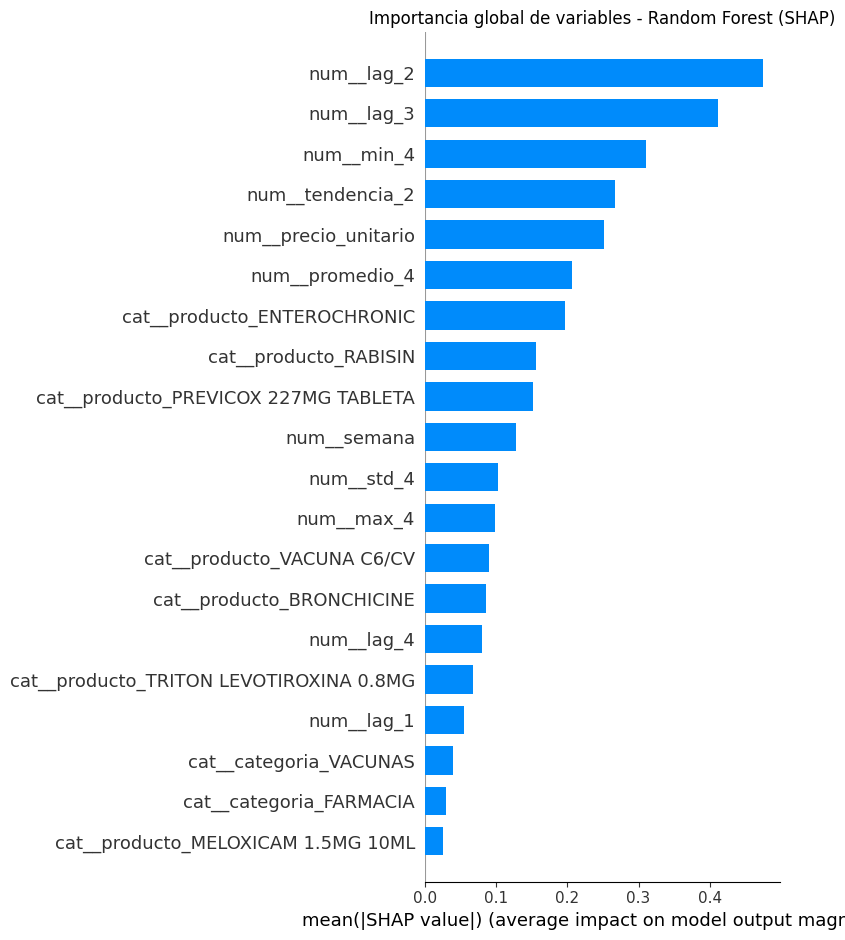

In [44]:
# =========================================================
# SHAP SUMMARY BAR PLOT
# =========================================================

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_shap,
    plot_type="bar",
    show=False
)

plt.title("Importancia global de variables - Random Forest (SHAP)")
plt.tight_layout()
plt.savefig("/content/shap_summary_bar_rf.png", dpi=300, bbox_inches="tight")
plt.show()

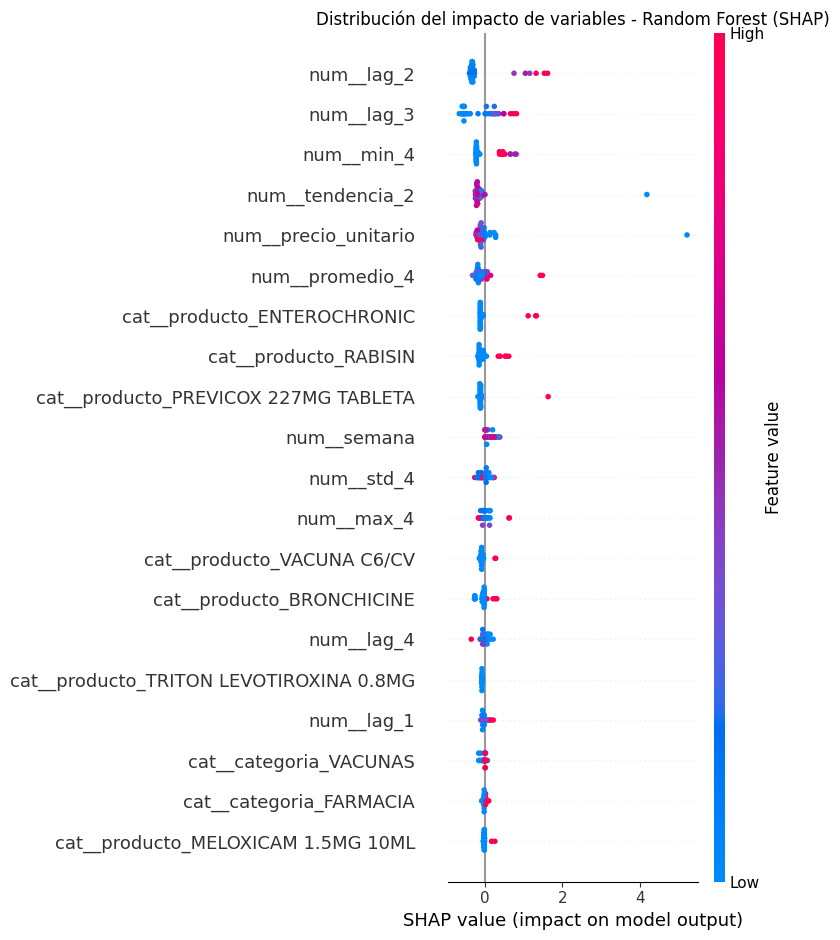

In [45]:
# =========================================================
# SHAP SUMMARY BEESWARM
# =========================================================

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_shap,
    show=False
)

plt.title("Distribución del impacto de variables - Random Forest (SHAP)")
plt.tight_layout()
plt.savefig("/content/shap_summary_beeswarm_rf.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
# =========================================================
# TOP VARIABLES MÁS INFLUYENTES
# =========================================================

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Variable": X_test_shap.columns,
    "Impacto_SHAP_promedio": mean_abs_shap
}).sort_values("Impacto_SHAP_promedio", ascending=False).reset_index(drop=True)

print("Top variables más influyentes:")
display(shap_importance.head(10))

# Guardar evidencia
shap_importance.to_csv("/content/shap_importancia_rf.csv", index=False)

Top variables más influyentes:


,Variable,Impacto_SHAP_promedio
0,num__lag_2,0.475021
1,num__lag_3,0.411467
2,num__min_4,0.310820
3,num__tendencia_2,0.266405
4,num__precio_unitario,0.251296
5,num__promedio_4,0.206060
6,cat__producto_ENTEROCHRONIC,0.196273
7,cat__producto_RABISIN,0.156015
8,cat__producto_PREVICOX 227MG TABLETA,0.151450
9,num__semana,0.128131


Variables seleccionadas para dependence plot: ['num__lag_1', 'num__promedio_4']


<Figure size 640x480 with 0 Axes>

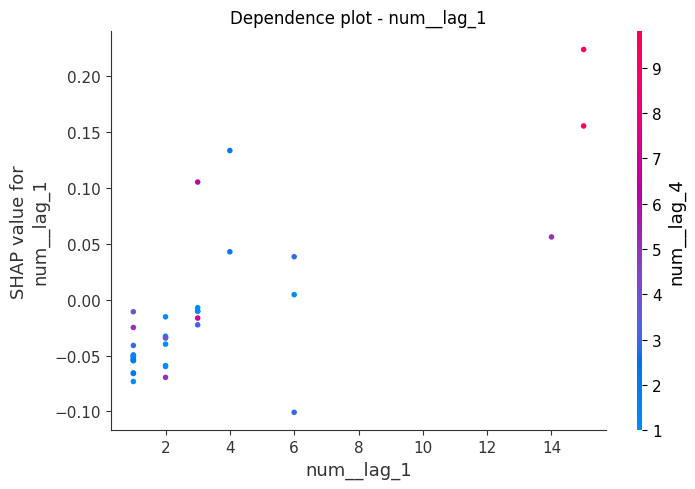

<Figure size 640x480 with 0 Axes>

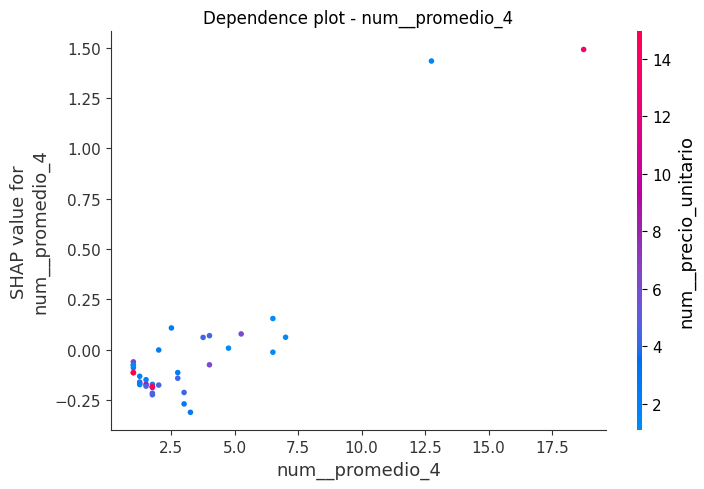

In [47]:
# =========================================================
# DEPENDENCE PLOTS
# =========================================================

variables_objetivo = []

for var in X_test_shap.columns:
    if "lag_1" in var or "promedio_4" in var:
        variables_objetivo.append(var)

print("Variables seleccionadas para dependence plot:", variables_objetivo)

for var in variables_objetivo[:2]:
    plt.figure()
    shap.dependence_plot(
        var,
        shap_values,
        X_test_shap,
        show=False
    )
    plt.title(f"Dependence plot - {var}")
    plt.tight_layout()
    safe_name = var.replace("/", "_").replace(" ", "_")
    plt.savefig(f"/content/dependence_{safe_name}.png", dpi=300, bbox_inches="tight")
    plt.show()

In [48]:
# =========================================================
# RESUMEN AUTOMÁTICO DEL ANÁLISIS SHAP
# =========================================================

top5 = shap_importance.head(5)["Variable"].tolist()

resumen_shap = f"""
Resumen automático de interpretabilidad (SHAP)

El análisis de interpretabilidad se realizó sobre el modelo Random Forest ajustado, utilizando la técnica SHAP para identificar la contribución de cada variable a las predicciones del modelo. Los resultados muestran que las variables más influyentes fueron: {", ".join(top5)}.

En términos generales, las variables asociadas al comportamiento reciente del consumo, particularmente los rezagos y el promedio móvil, concentran la mayor importancia explicativa. Esto indica que el modelo se apoya principalmente en la historia reciente del consumo para estimar la demanda futura, lo cual es coherente con la naturaleza autoregresiva del problema.

Este hallazgo es consistente con los resultados globales del proyecto, donde el modelo baseline basado en promedio móvil de cuatro semanas mantiene el mejor desempeño predictivo. En consecuencia, el análisis SHAP no solo aporta interpretabilidad al modelo de machine learning, sino que también refuerza la conclusión de que la señal principal del problema está determinada por patrones temporales simples y recientes.
"""

print(resumen_shap)

with open("/content/resumen_shap_novapet.txt", "w", encoding="utf-8") as f:
    f.write(resumen_shap)

print("Archivo guardado: /content/resumen_shap_novapet.txt")


Resumen automático de interpretabilidad (SHAP)

El análisis de interpretabilidad se realizó sobre el modelo Random Forest ajustado, utilizando la técnica SHAP para identificar la contribución de cada variable a las predicciones del modelo. Los resultados muestran que las variables más influyentes fueron: num__lag_2, num__lag_3, num__min_4, num__tendencia_2, num__precio_unitario.

En términos generales, las variables asociadas al comportamiento reciente del consumo, particularmente los rezagos y el promedio móvil, concentran la mayor importancia explicativa. Esto indica que el modelo se apoya principalmente en la historia reciente del consumo para estimar la demanda futura, lo cual es coherente con la naturaleza autoregresiva del problema.

Este hallazgo es consistente con los resultados globales del proyecto, donde el modelo baseline basado en promedio móvil de cuatro semanas mantiene el mejor desempeño predictivo. En consecuencia, el análisis SHAP no solo aporta interpretabilidad al 

In [49]:
# =========================================================
# INSERTAR SHAP + TEXTO EN WORD EXISTENTE
# =========================================================

from docx import Document
from docx.shared import Inches

doc_path = "/content/Reporte_Interpretabilidad_Etica_NovaPet.docx"  # ajusta este nombre
doc = Document(doc_path)

# ---------------------------------------------------------
# Agregar sección de interpretabilidad
# ---------------------------------------------------------
doc.add_heading("Análisis de interpretabilidad del modelo", level=1)

doc.add_paragraph(
    "Para el análisis de interpretabilidad se utilizó la técnica SHAP aplicada al modelo Random Forest ajustado, "
    "dado que permite cuantificar de forma clara la contribución de cada variable en la predicción. "
    "El baseline no fue sometido a esta técnica, ya que su lógica es inherentemente interpretable al basarse "
    "en el promedio móvil de las últimas cuatro semanas."
)

doc.add_paragraph(
    "Los resultados obtenidos mediante SHAP muestran que las variables más influyentes en el modelo corresponden "
    "principalmente al comportamiento reciente del consumo, especialmente los rezagos y el promedio móvil. "
    "Esto evidencia que el modelo fundamenta sus predicciones en la historia reciente del ítem, lo cual es coherente "
    "con la lógica operativa del problema y con los hallazgos generales del proyecto."
)

# Insertar gráfico 1
doc.add_picture("/content/shap_summary_bar_rf.png", width=Inches(5.8))
p = doc.add_paragraph()
r1 = p.add_run("Figura 1. ")
r1.bold = True
r2 = p.add_run("Importancia global de variables del modelo Random Forest ajustado mediante SHAP.")
r2.italic = True
doc.add_paragraph("Fuente: Elaboración propia.")

# Insertar gráfico 2
doc.add_picture("/content/shap_summary_beeswarm_rf.png", width=Inches(5.8))
p = doc.add_paragraph()
r1 = p.add_run("Figura 2. ")
r1.bold = True
r2 = p.add_run("Distribución del impacto de las variables en las predicciones del modelo Random Forest ajustado.")
r2.italic = True
doc.add_paragraph("Fuente: Elaboración propia.")

# Insertar resumen automático
doc.add_paragraph(resumen_shap)

# ---------------------------------------------------------
# Agregar sección ética
# ---------------------------------------------------------
doc.add_heading("Identificación de riesgos éticos", level=1)

doc.add_paragraph(
    "Desde una perspectiva ética, el análisis revela que el modelo depende fuertemente de datos históricos, "
    "lo que implica un riesgo de reproducir patrones operativos pasados, incluyendo posibles errores en el registro "
    "o decisiones históricas de reposición. Aunque no se identifican riesgos de discriminación directa asociados "
    "a atributos sensibles, sí existe riesgo de opacidad en los modelos más complejos y riesgo de uso indebido "
    "si las predicciones son interpretadas como decisiones automáticas e incuestionables."
)

doc.add_paragraph(
    "Por esta razón, el sistema debe ser entendido como una herramienta de apoyo a la decisión, no como un sustituto "
    "del criterio humano. Entre las principales estrategias de mitigación se propone mantener el baseline como referencia "
    "operativa, complementar las predicciones con supervisión humana, documentar explícitamente las limitaciones del modelo "
    "y continuar fortaleciendo la calidad y trazabilidad de los datos del Kardex."
)

# Guardar documento final
output_path = "/content/Reporte_Interpretabilidad_Etica_NovaPet_final.docx"
doc.save(output_path)

print("Documento final generado:", output_path)

Documento final generado: /content/Reporte_Interpretabilidad_Etica_NovaPet_final.docx


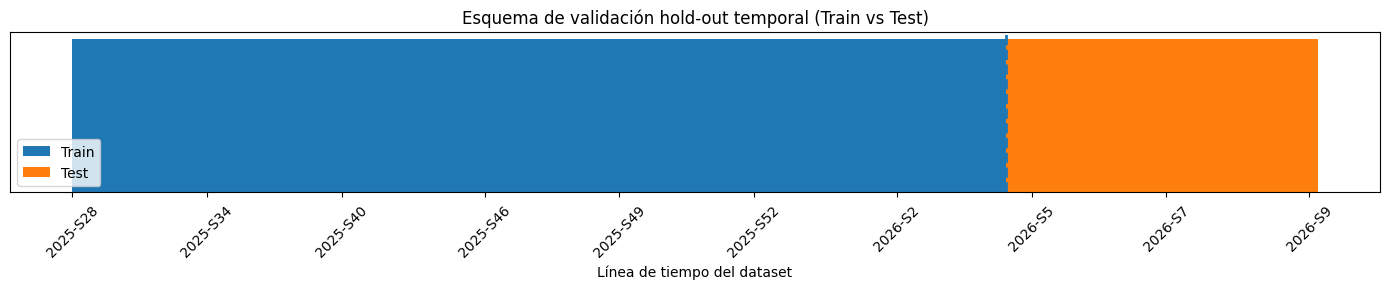

Gráfico guardado como: grafico_holdout_temporal.png


In [50]:
# =========================================================
# GRÁFICO HOLD-OUT TEMPORAL (TRAIN VS TEST)
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Asegúrate de tener dataset ordenado temporalmente
# Si tu dataset final se llama distinto, reemplaza 'dataset_ml'
df_holdout = dataset_ml_v2.copy()

# Ordenar por tiempo
df_holdout = df_holdout.sort_values(["anio", "semana"]).reset_index(drop=True)

# Tamaño del split temporal (75% train, 25% test)
train_size = int(len(df_holdout) * 0.75)

# Crear columna de partición
df_holdout["particion"] = ["Train" if i < train_size else "Test" for i in range(len(df_holdout))]

# Crear eje temporal legible
df_holdout["periodo"] = df_holdout["anio"].astype(str) + "-S" + df_holdout["semana"].astype(str)

# Crear gráfico
plt.figure(figsize=(14, 3))

# Línea base gris suave
plt.plot(range(len(df_holdout)), [1]*len(df_holdout), alpha=0)

# Pintar bloques
plt.bar(
    x=range(train_size),
    height=[1]*train_size,
    width=1.0,
    label="Train",
    align="edge"
)

plt.bar(
    x=range(train_size, len(df_holdout)),
    height=[1]*(len(df_holdout)-train_size),
    width=1.0,
    label="Test",
    align="edge"
)

# Línea divisoria
plt.axvline(train_size, linestyle="--", linewidth=2)

# Etiquetas de algunos periodos para no saturar
tick_positions = np.linspace(0, len(df_holdout)-1, min(10, len(df_holdout))).astype(int)
tick_labels = df_holdout.loc[tick_positions, "periodo"]

plt.xticks(tick_positions, tick_labels, rotation=45)
plt.yticks([])
plt.xlabel("Línea de tiempo del dataset")
plt.title("Esquema de validación hold-out temporal (Train vs Test)")
plt.legend()
plt.tight_layout()

# Guardar imagen para Word
plt.savefig("grafico_holdout_temporal.png", dpi=300, bbox_inches="tight")
plt.show()

print("Gráfico guardado como: grafico_holdout_temporal.png")